In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [4]:
foldername = 'results/20250422/'
pickels = glob.glob(f'{foldername}/*pkl')

if len(pickels) > 1:
    df_list = []
    for file in pickels:
        df_list.append(pd.read_pickle(file))

    df = pd.concat(df_list)
    #df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [5]:
print(df.shape)
df.head()

(1528, 21)


,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",25820,"[563.0, 166.0, 180.0, 183.0]",0.992188,"[[620.0, 195.0]]",0.990134,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",729,25819.0,...,90.657384,"(620.0, 195.0)",185.067555,175.405151,115.667222,113.321730,219.256439,A-01,A-immo,1.25
1,"[[False, False, False, False, False, False, Fa...",26005,"[813.0, 527.0, 183.0, 181.0]",0.992188,"[[900.0, 555.0]]",0.990695,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",733,26005.0,...,90.981584,"(900.0, 555.0)",185.000000,177.483795,115.625000,113.726980,221.854744,A-01,A-immo,1.25
2,"[[False, False, False, False, False, False, Fa...",25190,"[1010.0, 450.0, 182.0, 177.0]",0.992188,"[[1060.0, 465.0]]",0.990635,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",723,25192.0,...,89.544548,"(1060.0, 465.0)",183.133831,174.359497,114.458644,111.930685,217.949371,A-01,A-immo,1.25
3,"[[False, False, False, False, False, False, Fa...",25949,"[562.0, 165.0, 360.0, 184.0]",0.984375,"[[660.0, 165.0]]",0.988077,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",733,25940.0,...,90.883570,"(660.0, 165.0)",185.809042,175.695496,116.130651,113.604462,219.619370,A-01,A-immo,1.25
4,"[[False, False, False, False, False, False, Fa...",25948,"[697.0, 527.0, 298.0, 412.0]",0.953125,"[[900.0, 525.0]]",0.990145,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",731,25943.0,...,90.881818,"(900.0, 525.0)",185.205292,177.011780,115.753307,113.602273,221.264725,A-01,A-immo,1.25


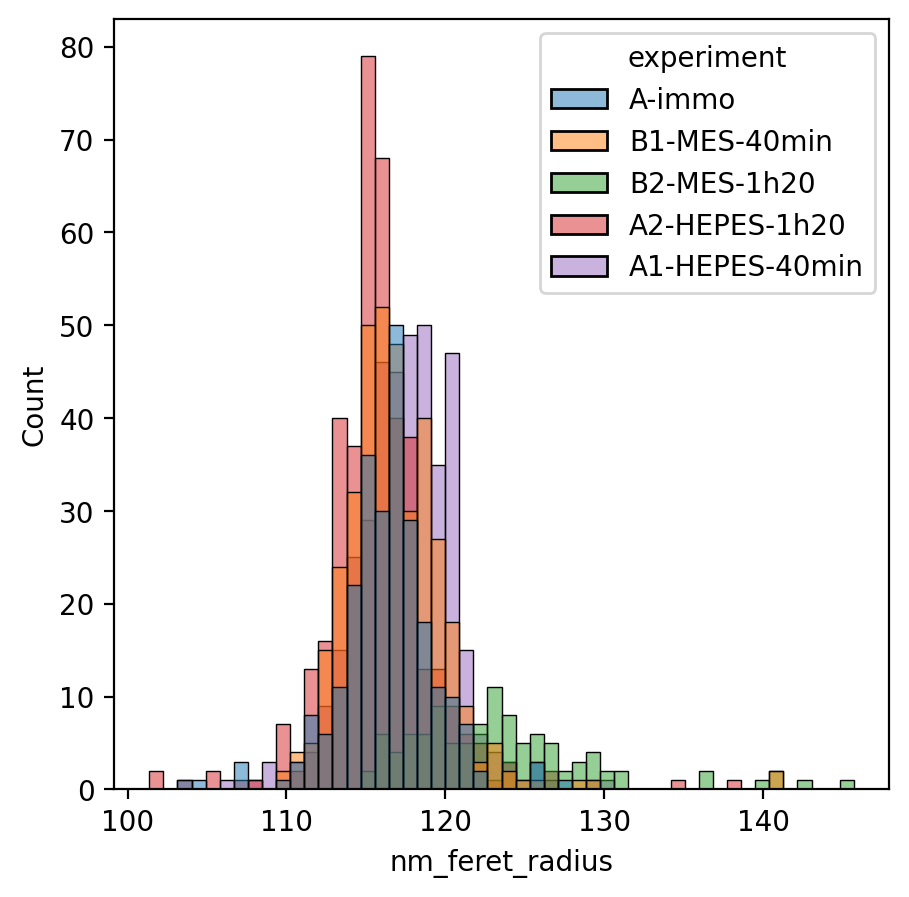

In [6]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [7]:
#exclusion_list = ['A1-01', 'A1-04', 'A1-02', 'B3-01','B2-05','B2-04','B2-03','B2-02'] #20250224
#exclusion_list = [ 'A1-04', 'A1-12', 'A1-17','A1-18','A1-19', 'A2-08', 'A3-15', 'A3-16', 'A3-17', 'A3-20'] #20250324
exclusion_list = [] #20250324-sam2

In [8]:
df_exluded = df[~df['img_name'].isin(exclusion_list)]
df_exluded.shape

(1528, 21)

In [9]:
df_exluded = df_exluded.query("circularity > 0.65")
df_exluded.shape

(1528, 21)

In [13]:
df_exluded['hough_radius'] = df_exluded.apply(lambda x: get_hough_radius(x['smooth_mask'], 
                                                                           dp=2, 
                                                                           nm_min_radius=70, 
                                                                           nm_max_radius=150, 
                                                                           nm_per_pixel=x['nm_per_pixel'], 
                                                                           convert_to_nm=True), axis=1)

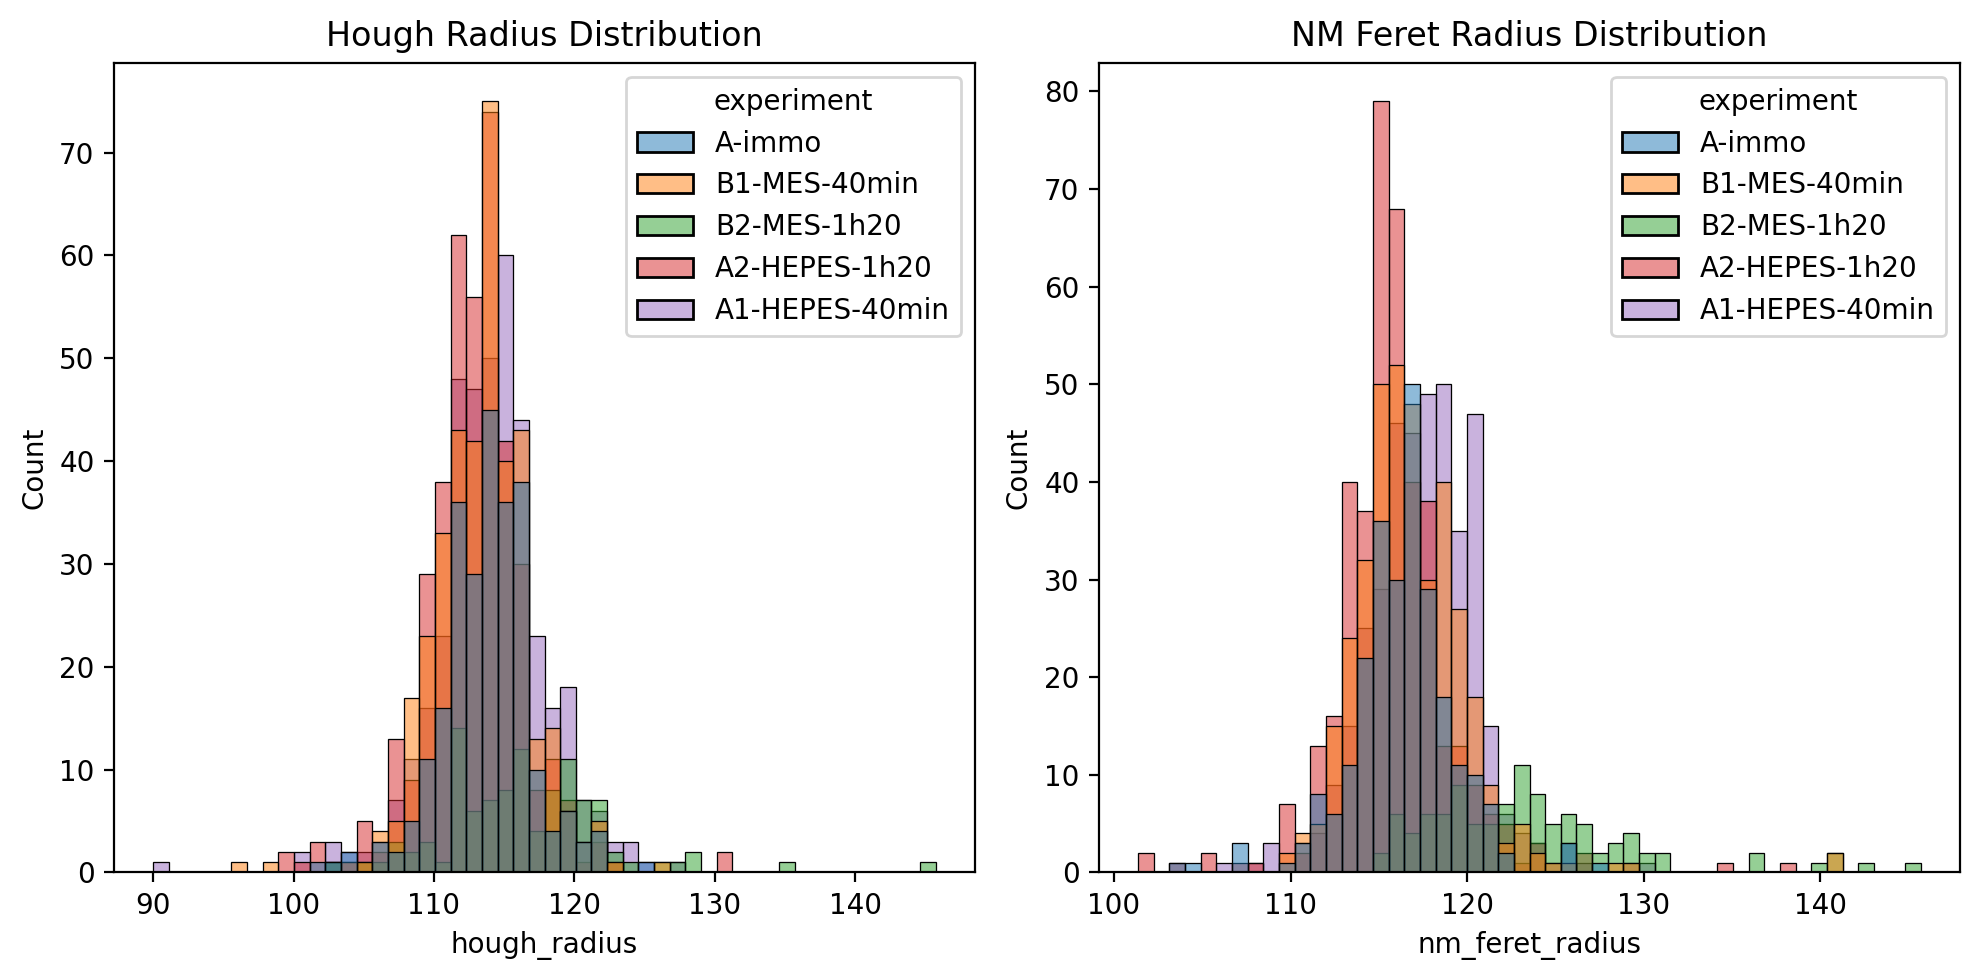

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=df_exluded.dropna(), x='hough_radius', hue='experiment', bins=50, ax=axes[0])
axes[0].set_title("Hough Radius Distribution")

sns.histplot(data=df_exluded.dropna(), x='nm_feret_radius', hue='experiment', bins=50, ax=axes[1])
axes[1].set_title("NM Feret Radius Distribution")
plt.tight_layout()

# Save the figure
plt.savefig(f'{foldername}/unfiltered_measurements')
plt.show()

In [15]:
#filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 

def filter_multiple(df, filters):
    '''quantile filtering for multiple filters'''
    for filter_quantity in filters:
        if filter_quantity in df.columns:
            q5, q95 = df[filter_quantity].quantile([0.05, 0.95])
            df = df[(df[filter_quantity] < q95) & (df[filter_quantity] > q5)]
        else:
            print(f'{filter_quantity} not found in dataframe')
    return df

df_filtered = filter_multiple(df_exluded, ['nm_feret_radius', 'hough_radius'])
df_filtered.shape

(1233, 22)

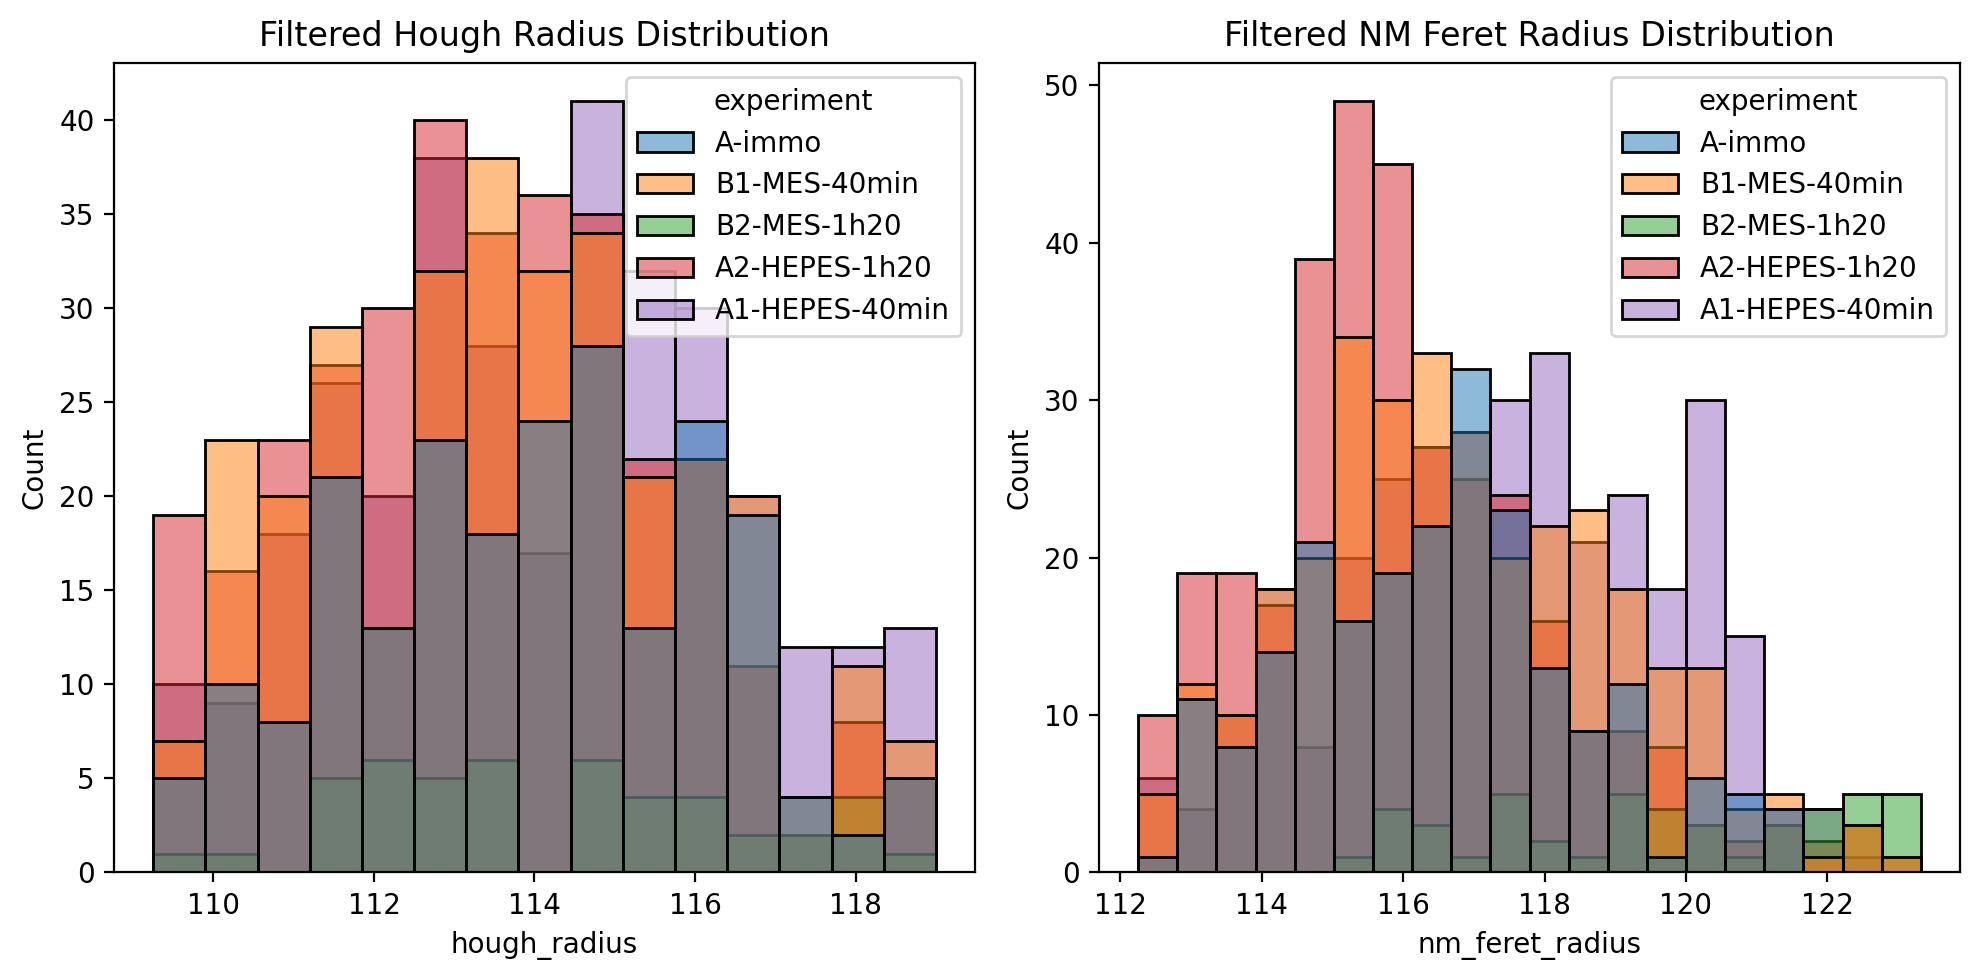

In [16]:
plot_df = df_filtered.dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=plot_df, x='hough_radius', hue='experiment', ax=axes[0])
axes[0].set_title("Filtered Hough Radius Distribution")

sns.histplot(data=plot_df, x='nm_feret_radius', hue='experiment', ax=axes[1])
axes[1].set_title("Filtered NM Feret Radius Distribution")

plt.tight_layout()

plt.savefig(f'{foldername}/filtered_particle_measurements')
plt.show()


<Figure size 1000x1000 with 0 Axes>

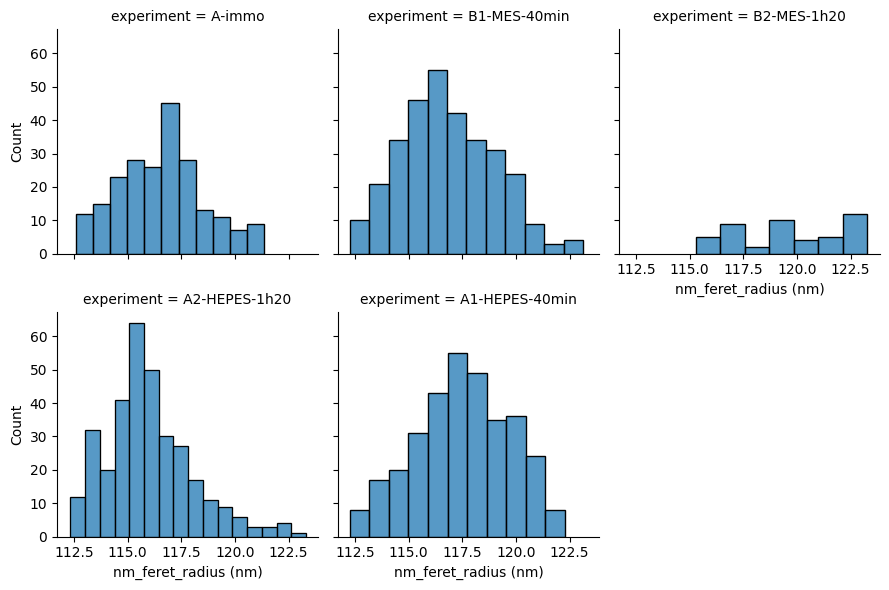

In [17]:
filter_quantity = 'nm_feret_radius'

plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [18]:
df_filtered['avg'] = (df_filtered.hough_radius + df_filtered.nm_feret_radius)/2

In [19]:
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=['hough_radius', 'nm_feret_radius', 'avg'])
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

hough_radius                                                        \
experiment       A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min B2-MES-1h20   
0                113.75         113.75        114.25       113.00      114.50   
1                112.75         116.00        114.50       111.50      113.75   
2                110.00         115.25        114.00       116.25      117.00   
3                109.75         113.00        113.75       118.50      112.00   
4                116.00         117.25        114.75       113.00      118.25   

           nm_feret_radius                                            \
experiment          A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min   
0               115.667222     119.193252    112.974693   115.874730   
1               115.625000     117.813743    117.526593   116.150831   
2               114.458644     118.651275    116.734541   117.010283   
3               116.130651     119.327543    114.976220   120.125260   
4               115.753307     121.006521    118.547525   119.176864   

                               avg                                            \
experiment B2-MES-1h20      A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min   
0           119.193252  114.708611     116.471626    113.612346   114.437365   
1           122.758019  114.187500     116.906872    116.013296   113.825416   
2           118.257201  112.229322     116.950637    115.367271   116.630141   
3           123.015497  112.940326     116.163771    114.363110   119.312630   
4           122.812102  115.876654     119.128261    116.648762   116.088432   

                        
experiment B2-MES-1h20  
0           116.846626  
1           118.254010  
2           117.628601  
3           117.507748  
4           120.531051

In [20]:
experiment_df.describe().to_excel(f'{foldername}/individual-particle-analysis.xlsx')
experiment_df.describe()

hough_radius                                                        \
experiment       A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min B2-MES-1h20   
count        217.000000     326.000000    330.000000   313.000000   47.000000   
mean         113.950461     114.125767    113.368497   113.709617  114.228723   
std            2.164160       2.348219      2.147229     2.251694    2.332328   
min          109.500000     109.250000    109.250000   109.250000  109.250000   
25%          112.250000     112.250000    111.750000   111.750000  112.250000   
50%          114.000000     114.250000    113.250000   113.750000  113.750000   
75%          115.500000     115.750000    114.750000   115.250000  115.750000   
max          119.000000     119.000000    118.750000   119.000000  118.500000   

           nm_feret_radius                                            \
experiment          A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min   
count           217.000000     326.000000    330.000000   313.000000   
mean            116.568039     117.485471    116.019179   116.812977   
std               1.962862       2.205544      2.041637     2.188628   
min             112.597180     112.256681    112.327994   112.267120   
25%             115.015284     115.994342    114.734748   115.179886   
50%             116.627412     117.468413    115.722931   116.640808   
75%             117.639545     119.187516    117.123894   118.376056   
max             121.353049     122.286165    123.319960   123.125000   

                               avg                                            \
experiment B2-MES-1h20      A-immo A1-HEPES-40min A2-HEPES-1h20 B1-MES-40min   
count        47.000000  217.000000     326.000000    330.000000   313.000000   
mean        119.671057  115.259250     115.805619    114.693838   115.261297   
std           2.461989    1.860933       2.011577      1.838901     1.913058   
min         115.284973  111.528823     110.793344    111.197858   110.758560   
25%         117.445963  113.747452     114.287380    113.354035   113.961666   
50%         119.786594  115.324590     115.891398    114.565541   115.193349   
75%         122.099132  116.498963     117.266552    115.859530   116.697526   
max         123.283527  120.132248     120.479152    120.616230   121.062500   

                        
experiment B2-MES-1h20  
count        47.000000  
mean        116.949890  
std           2.035795  
min         113.250034  
25%         115.269612  
50%         116.953041  
75%         118.691522  
max         120.531051

In [25]:
method =  'hough_radius' 
method = 'nm_feret_radius' 
#method = 'avg' 


analysis_df = analyze_samples(experiment_df[method], 'A-immo', alpha=0.01)
#analysis_df.to_csv(f'{foldername}/shield-analysis.csv')
analysis_df.to_excel(f'{foldername}/shield-analysis_{method}.xlsx')
analysis_df

,A1-HEPES-40min,A2-HEPES-1h20,B1-MES-40min,B2-MES-1h20
thickness,0.917433,-0.548859,0.244939,3.103019
CI_lower,0.450018,-0.99968,-0.225215,2.083626
CI_upper,1.384848,-0.098039,0.715092,4.122412
p_value,0.000001,0.001744,0.178551,0.0
significance,Significant,Significant,Not significant,Significant
significance_level,99.5,99.5,99.5,99.5
SEM,0.180766,0.174316,0.181821,0.383041
DOF,497.898166,474.863842,494.494448,59.298329
N_sample,326,330,313,47
N_ref,217,217,217,217


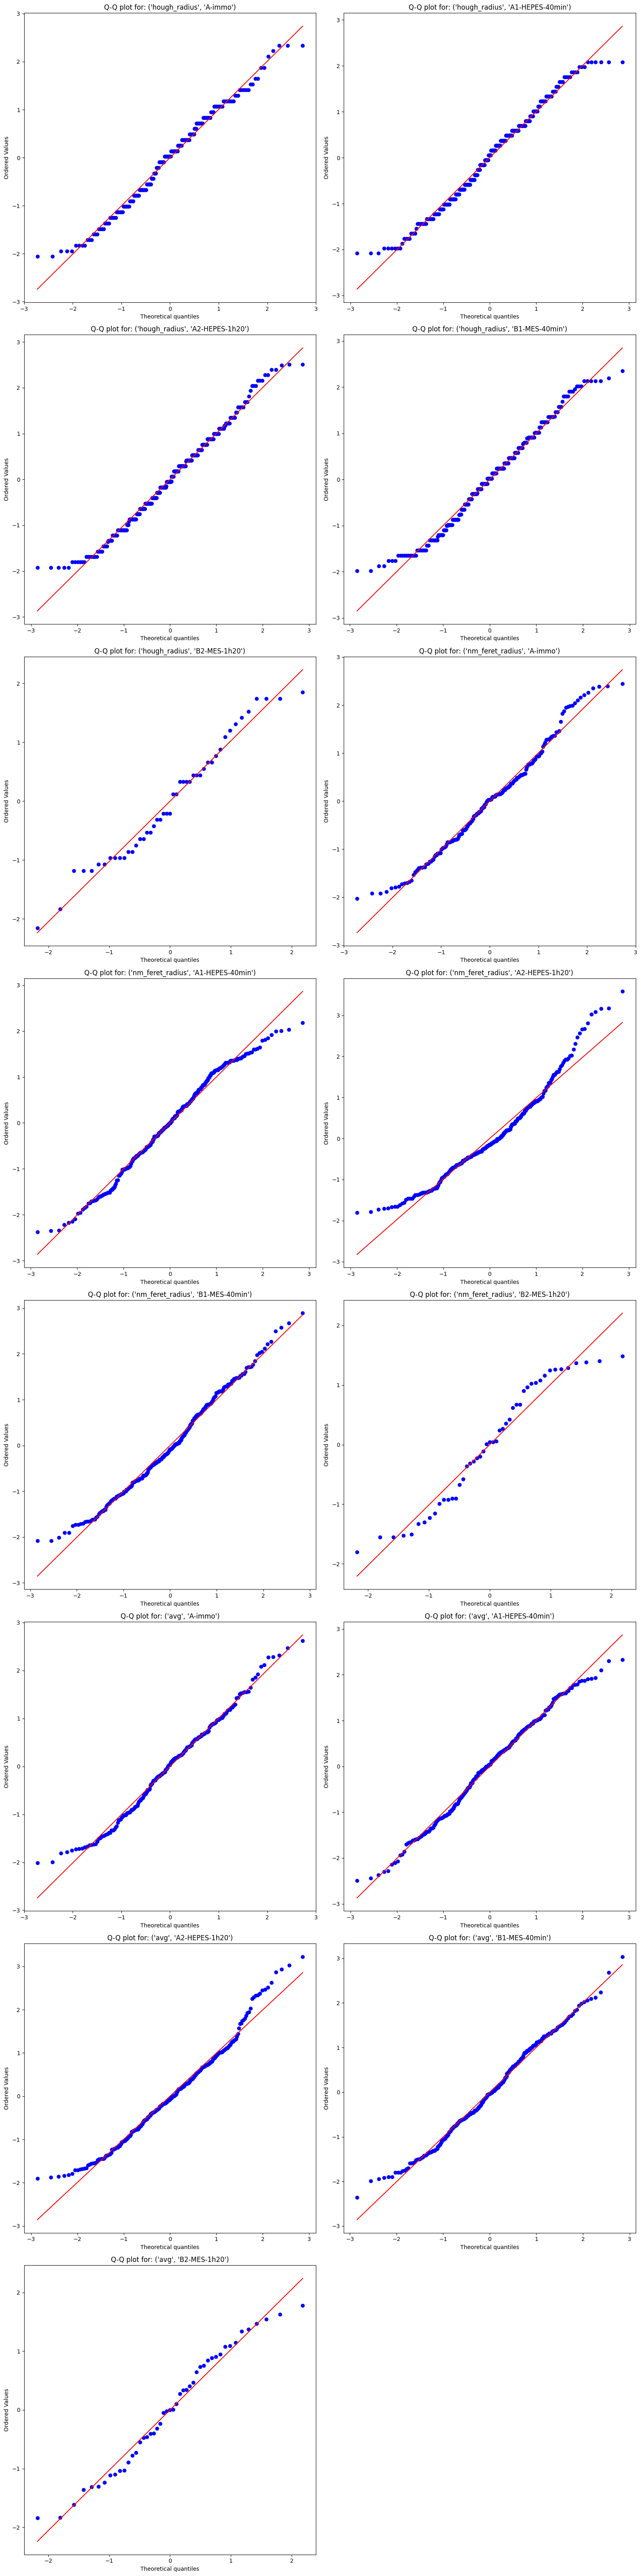

<Figure size 640x480 with 0 Axes>

In [26]:
plot_quantiles(experiment_df, foldername)
